## Granulocyte figures

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

# custom functions
import sc_toolbox as sct

Running Scanpy 1.8.2, on 2024-12-05 17:07.


In [2]:
## path variables
adata_dir = '/mnt/smb2/Niklas/GLPG_data_temp/subsets/240730_granulocyte_subset_NIKLAS_annotated.h5ad'
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/'
out_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig2/'

In [3]:
## plotting variables
sc.settings.figdir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig2/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load anndata object
adata = sc.read(adata_dir)

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/mnt/smb2/Niklas/GLPG_data_temp/subsets/240730_granulocyte_subset_NIKLAS_annotated.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [5]:
## have a look at the adata object: 23,970 cells
adata

AnnData object with n_obs × n_vars = 23970 × 13770
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'GLPG_annotation', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'd_cluster', 'sub_louvain', 'cell_type'
    var: 'means', 'dispersions', 'dispersions_norm', 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'GLPG_annotation_colors', 'cell_type_colors', 'cluster_03_colors', 'condition_colors', 'd_cluster_colors', 'dendrogram_cell_type', 'dendrogram_sub_louvain', 'hvg', 'identifier_colors', 'louvain', 'louvain_1_colors', 'neighbors', 'pca', 'rank_genes_groups', 'sub_louvain_colors', 'time_point_colors', 'treatment_colors', 'treatment_time_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'unsouped_counts'
    obsp: 'connectivitie

### Color palettes

In [6]:
timepoint_colors = ['#6A1B9A', '#FFD700']
condition_colors = ['#1A237E', '#FFAB91']
treatment_colors = ['#D3D3D3', '#606060', '#2E59A8', '#C93333', '#FFA500', '#20B2AA']

In [7]:
## modifications of 'treatment_colors'
treatment_time_colors =  [
    '#D3D3D3', '#A9A9A9',  # Light Grey Pair
    '#606060', '#202020',  # Dark Grey Pair
    '#2E59A8', '#1A3B6F',  # Blue Pair
    '#C93333', '#8B2323',  # Red Pair
    '#FFA500', '#CC7000',  # Orange Pair
    '#20B2AA', '#006D6D'   # Teal Pair
]

In [8]:
## cell type colors should be consistent with overview figure
cell_type_colors = [
    '#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00',
    '#FFFF33', '#A65628', '#F781BF', '#999999', '#004301',
    '#00FFFF', '#00008F', '#5F0029', '#D3D3D3', '#4F4E51',
    '#B499FF', '#6700F9', '#4D006F', '#00806C', '#72FF9A',
    '#6A6C00', '#E1C78B', '#63C1FE', '#D90083', '#5A3500',
    '#42BBA9', '#B29A00', '#F203FF', '#920000', '#004F74',
    '#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD',
    '#8C564B', '#E377C2', '#7F7F7F', '#BCBD22', '#17BECF',
    '#A6CEE3', '#1F78B4', '#B2DF8A', '#33A02C', '#FB9A99',
    '#E31A1C', '#FDBF6F', '#FF7F00', '#CAB2D6', '#6A3D9A',
    '#FFFF99', '#B15928', '#B3E2CD', '#FDCDAC', '#CBD5E8',
    '#F4CAE4', '#E6F5C9', '#FFF2AE', '#F1E2CC', '#CCCCCC',
    '#1B9E77', '#D95F02', '#7570B3', '#E7298A'
]
## subset full list
granulocyte_colors = cell_type_colors[-13:-19:-1]

In [9]:
granulocyte_colors

['#B15928', '#FFFF99', '#6A3D9A', '#CAB2D6', '#FF7F00', '#FDBF6F']

In [10]:
granulocyte_colors = ['#B15928', '#FFFF99', '#6A3D9A', '#CAB2D6', '#FF7F00', '#D32F2F']

### Summary Figures

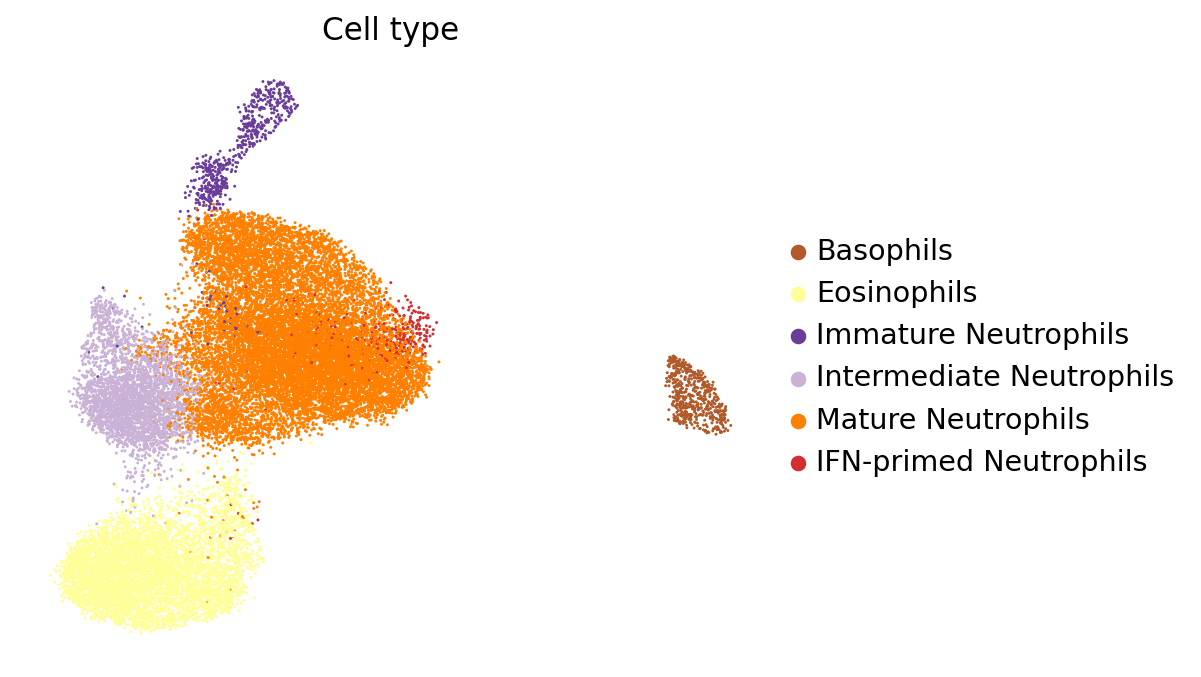

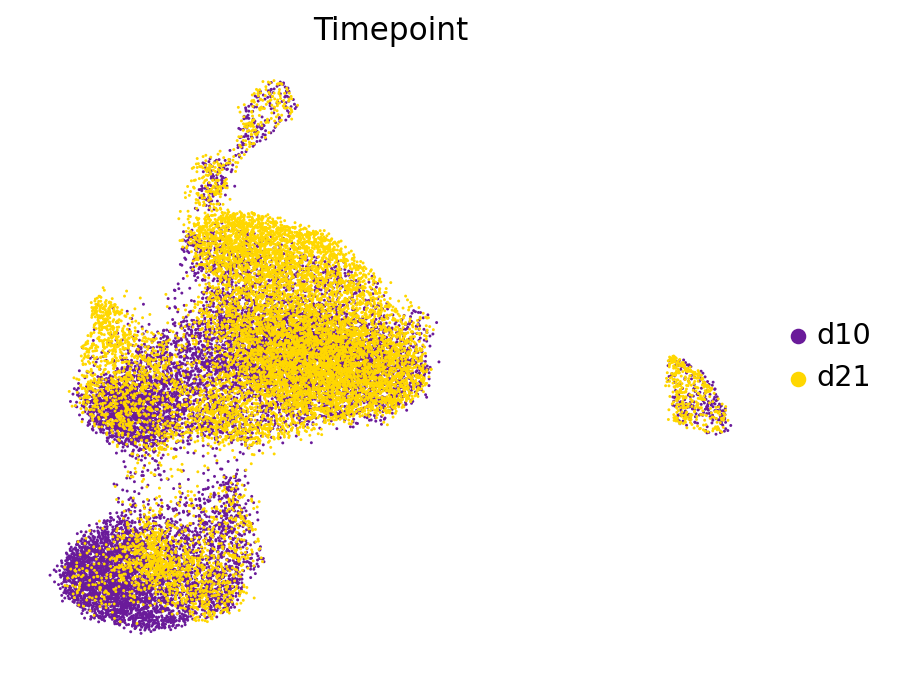

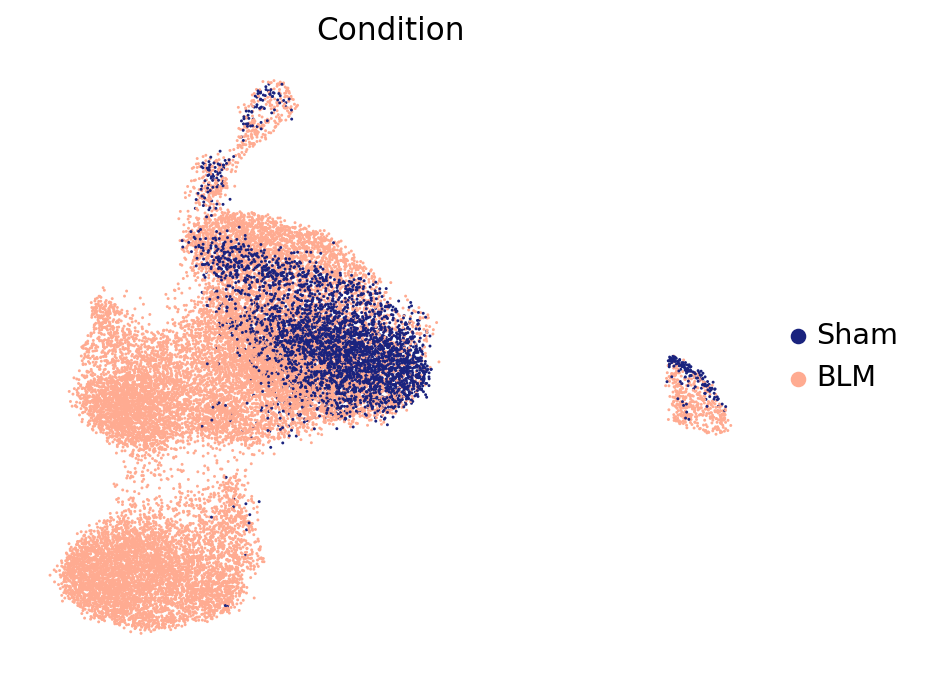

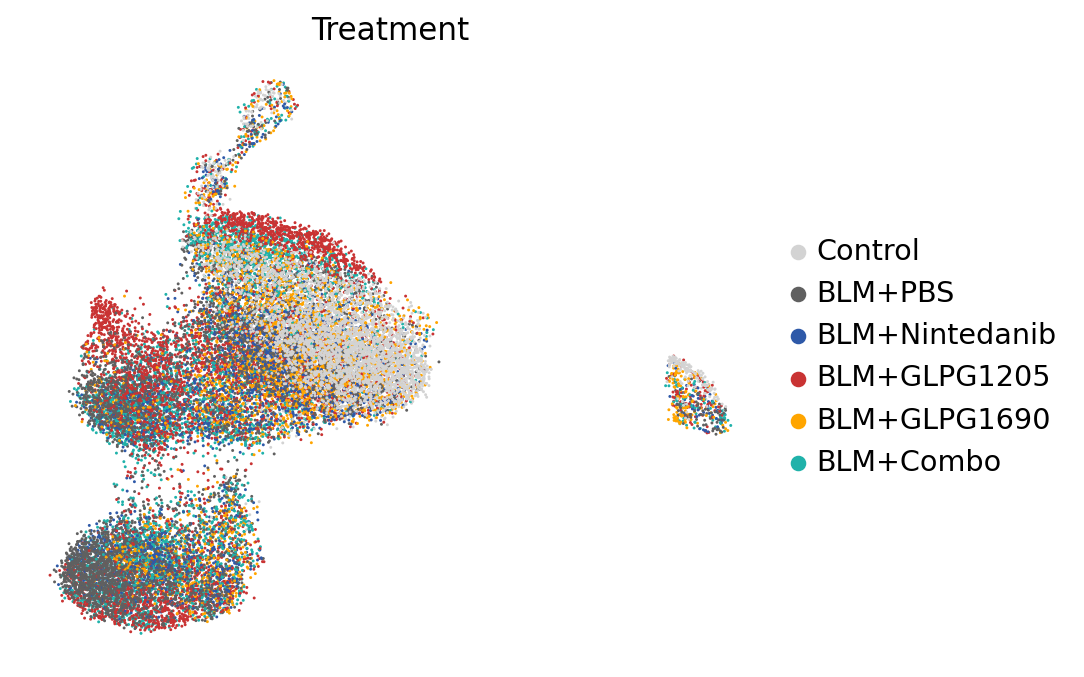

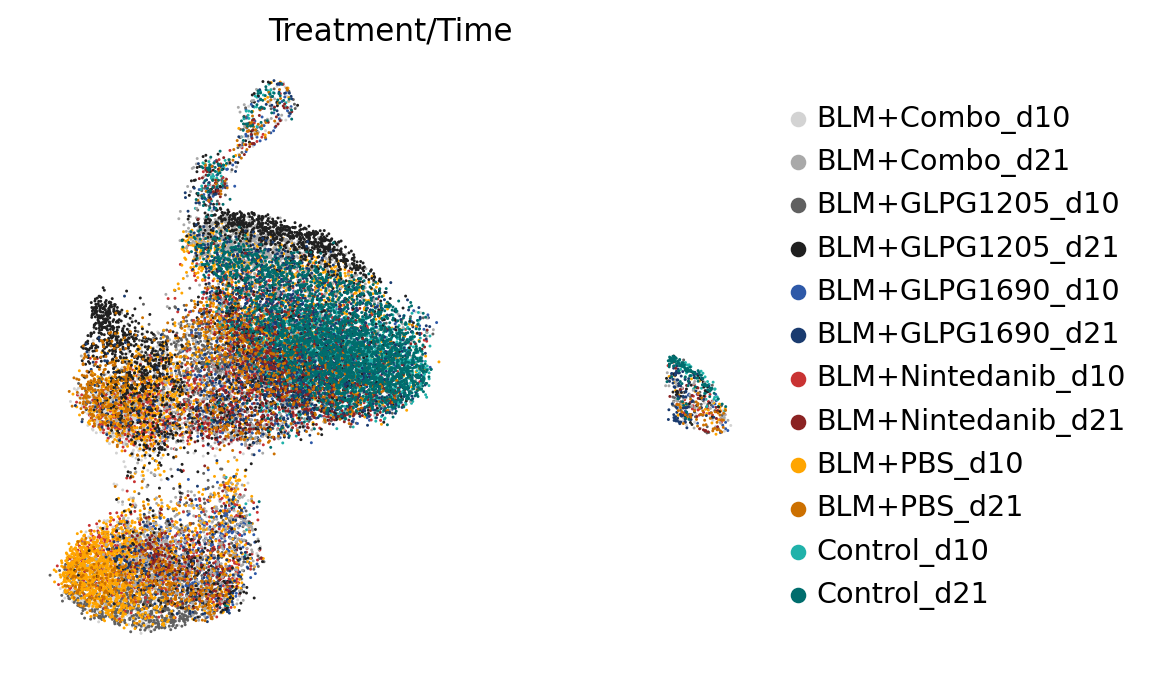

In [11]:
## save UMAP for presentation
sc.pl.umap(adata, color = ['cell_type'], title = 'Cell type', frameon = False, palette = granulocyte_colors, size = 7,
           save = '_celltype.pdf')
sc.pl.umap(adata, color = ['time_point'], title = 'Timepoint', frameon = False, palette = timepoint_colors, size = 7,
           save = '_timepoint.pdf')
sc.pl.umap(adata, color = ['condition'], title = 'Condition', frameon = False, palette = condition_colors, size = 7,
           save = '_condition.pdf')
sc.pl.umap(adata, color = ['treatment'], title = 'Treatment', frameon = False, palette = treatment_colors, size = 7,
           save = '_treatment.pdf')
sc.pl.umap(adata, color = ['treatment_time'], title = 'Treatment/Time', frameon = False, palette = treatment_time_colors, size = 7,
           save = '_treatment_time.pdf')

### Marker gene calculation and visualisation

In [12]:
sc.tl.rank_genes_groups(adata, groupby='cell_type', method='wilcoxon')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:12)


In [13]:
## filter marker genes
sc.tl.filter_rank_genes_groups(adata, min_fold_change=2, min_in_group_fraction = 0.5, max_out_group_fraction = 0.25)

Filtering genes using: min_in_group_fraction: 0.5 min_fold_change: 2, max_out_group_fraction: 0.25


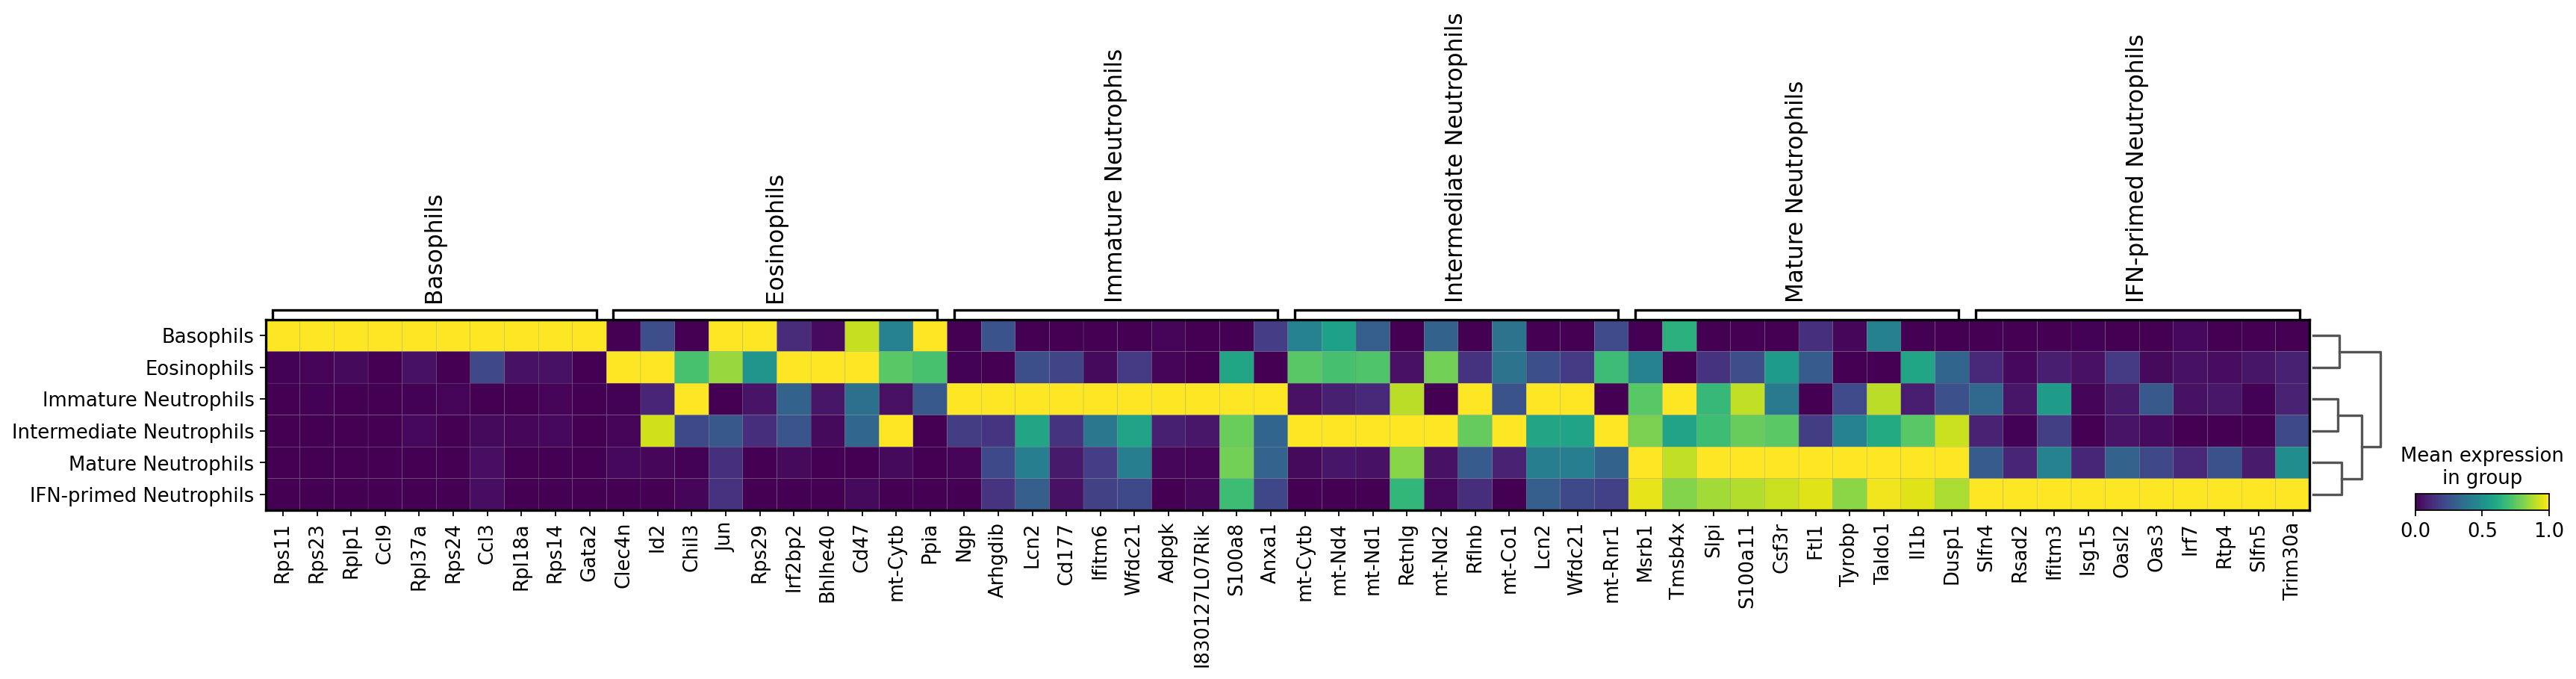

In [14]:
## matrix plot per cell type with top 5 genes per cell type
sc.pl.rank_genes_groups_matrixplot(adata, 
                                   n_genes = 10, 
                                   standard_scale = 'var', 
                                   groupby = 'cell_type',
                                   save= 'auto_markers.pdf')

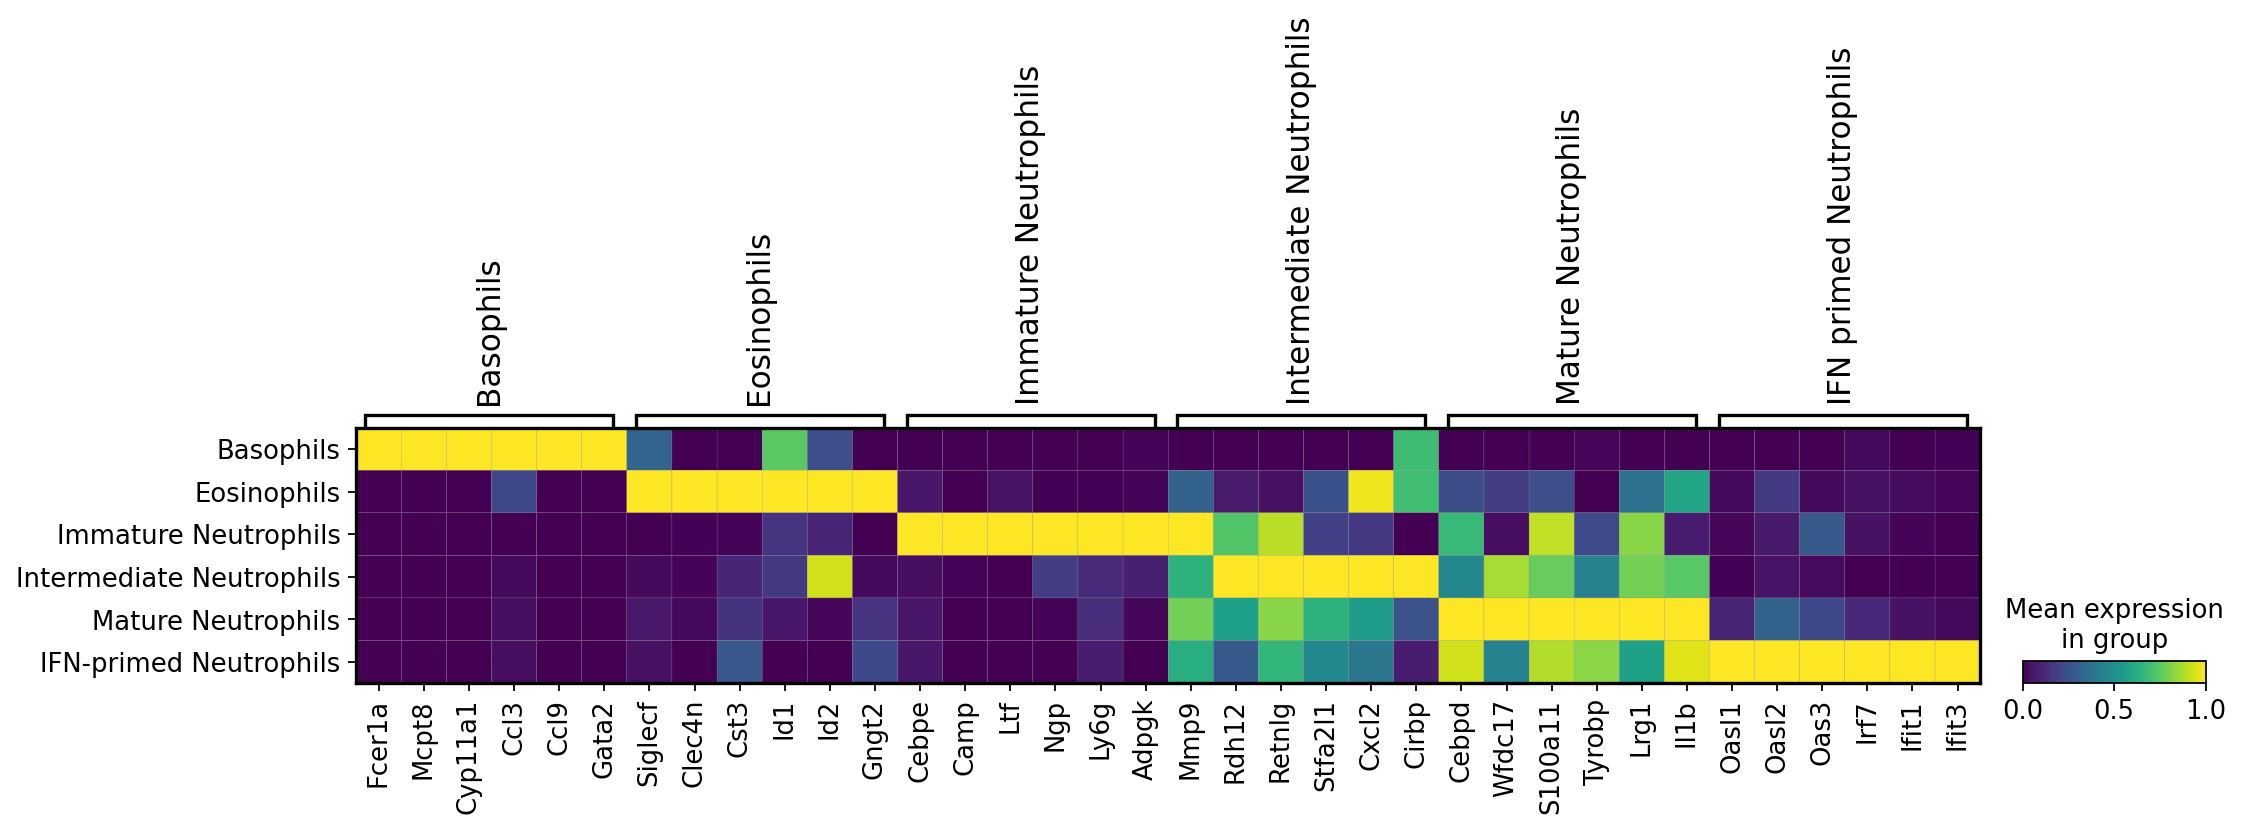

In [15]:
## custom heatmap
# matrixplot with marker genes
celltype_markers={'Basophils' : ['Fcer1a','Mcpt8','Cyp11a1','Ccl3','Ccl9','Gata2'],
                  'Eosinophils' : ['Siglecf','Clec4n','Cst3','Id1','Id2','Gngt2'],
                  'Immature Neutrophils' : ['Cebpe','Camp','Ltf','Ngp','Ly6g','Adpgk'],
                  'Intermediate Neutrophils' : ['Mmp9','Rdh12','Retnlg','Stfa2l1','Cxcl2','Cirbp'],
                  'Mature Neutrophils' : ['Cebpd','Wfdc17','S100a11','Tyrobp','Lrg1','Il1b'],
                  'IFN primed Neutrophils' : ['Oasl1','Oasl2','Oas3','Irf7','Ifit1','Ifit3']
                 }
sc.pl.matrixplot(adata, celltype_markers, groupby = 'cell_type',standard_scale='var',
                 dendrogram=False, save='curated_marker_matrix.pdf')

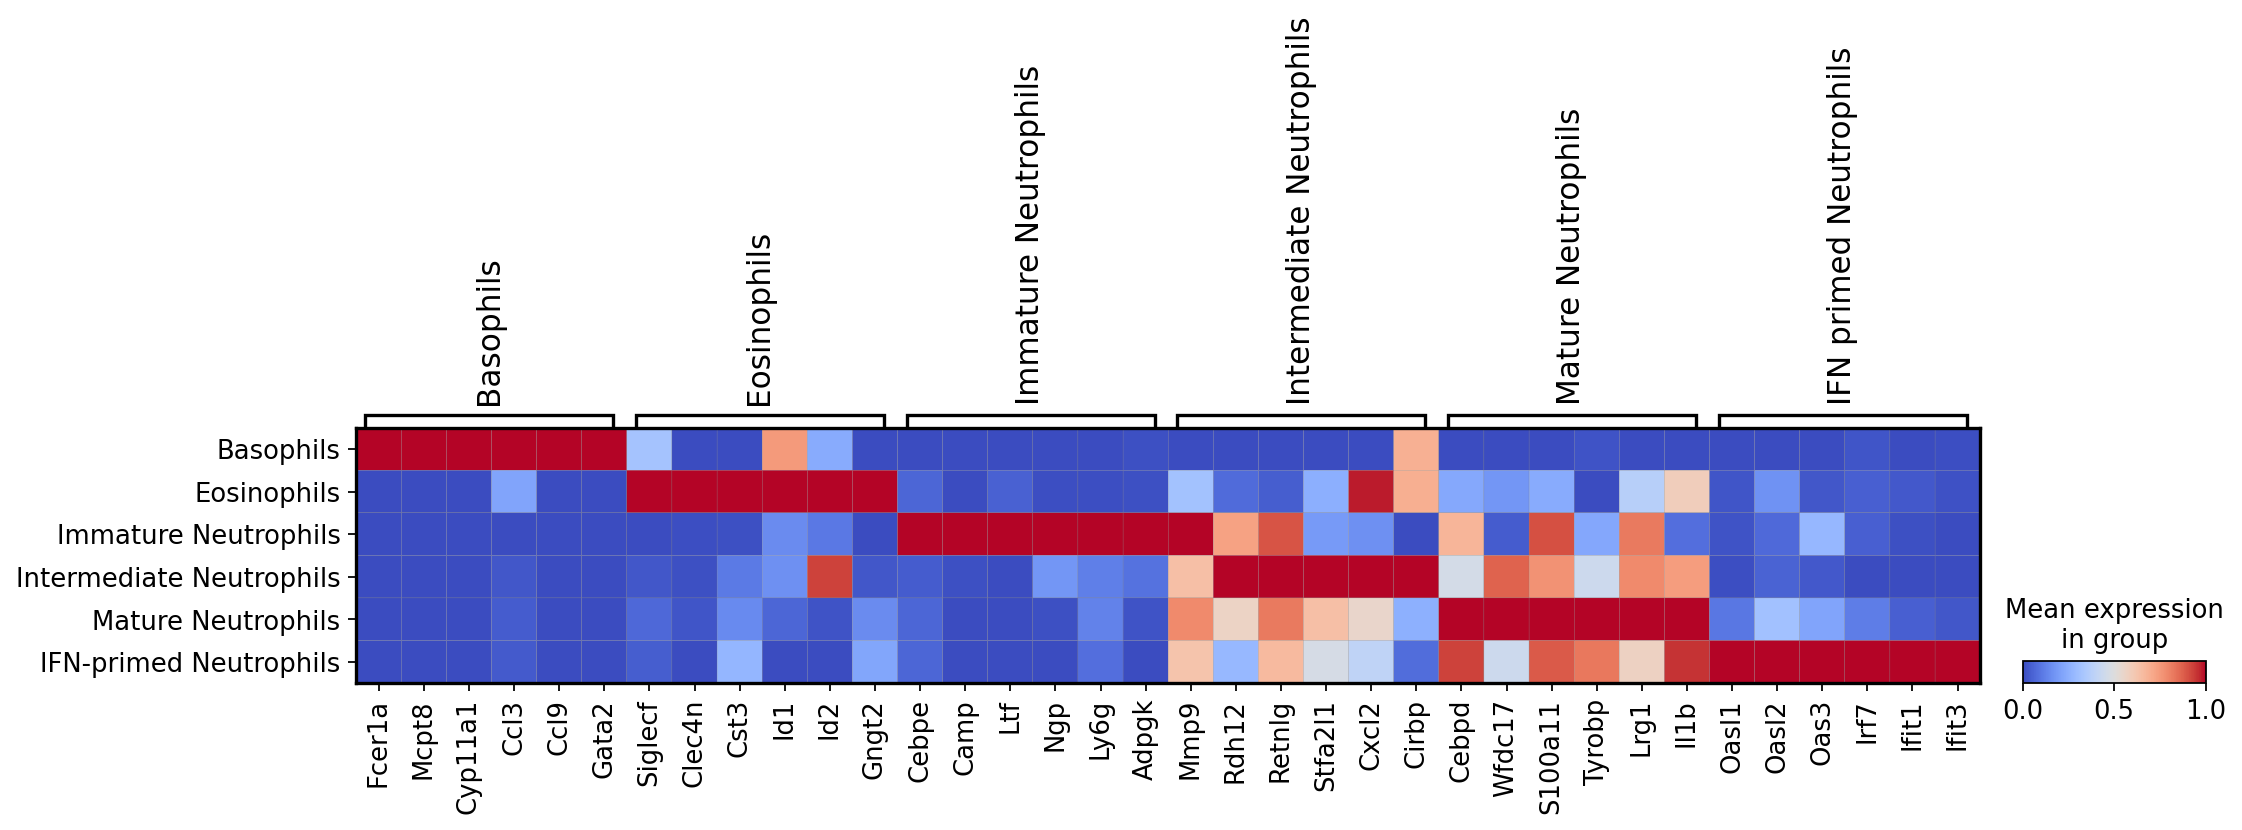

In [16]:
## custom heatmap
# matrixplot with marker genes
celltype_markers={'Basophils' : ['Fcer1a','Mcpt8','Cyp11a1','Ccl3','Ccl9','Gata2'],
                  'Eosinophils' : ['Siglecf','Clec4n','Cst3','Id1','Id2','Gngt2'],
                  'Immature Neutrophils' : ['Cebpe','Camp','Ltf','Ngp','Ly6g','Adpgk'],
                  'Intermediate Neutrophils' : ['Mmp9','Rdh12','Retnlg','Stfa2l1','Cxcl2','Cirbp'],
                  'Mature Neutrophils' : ['Cebpd','Wfdc17','S100a11','Tyrobp','Lrg1','Il1b'],
                  'IFN primed Neutrophils' : ['Oasl1','Oasl2','Oas3','Irf7','Ifit1','Ifit3']
                 }
sc.pl.matrixplot(adata, celltype_markers, groupby = 'cell_type',standard_scale='var', cmap='coolwarm',
                 dendrogram=False 
                 #save='curated_marker_matrix.pdf'
                )

### Relative frequency changes

In [16]:
## frequency table
xlabel = 'treatment'
cell_types_label = 'cell_type'
cols = adata.uns['%s_colors' %cell_types_label]
celltypes = adata.obs[cell_types_label].cat.categories

relFreqs = sct.calc.relative_frequencies(adata, group_by = cell_types_label, xlabel = xlabel, condition = None)
relFreqs.head(2)

,Basophils,Eosinophils,Immature Neutrophils,Intermediate Neutrophils,Mature Neutrophils,IFN-primed Neutrophils,treatment
d100BLM_Combo48,0.0,0.291312,0.005111,0.691652,0.011925,0.000000,BLM+Combo
d100BLM_G120528,0.0,0.158055,0.009119,0.364742,0.462006,0.006079,BLM+GLPG1205


In [17]:
order = ['Control','BLM+PBS','BLM+Nintedanib','BLM+GLPG1205','BLM+GLPG1690','BLM+Combo']

Saving Figure to 
/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig2/relfreqs_treatment.pdf

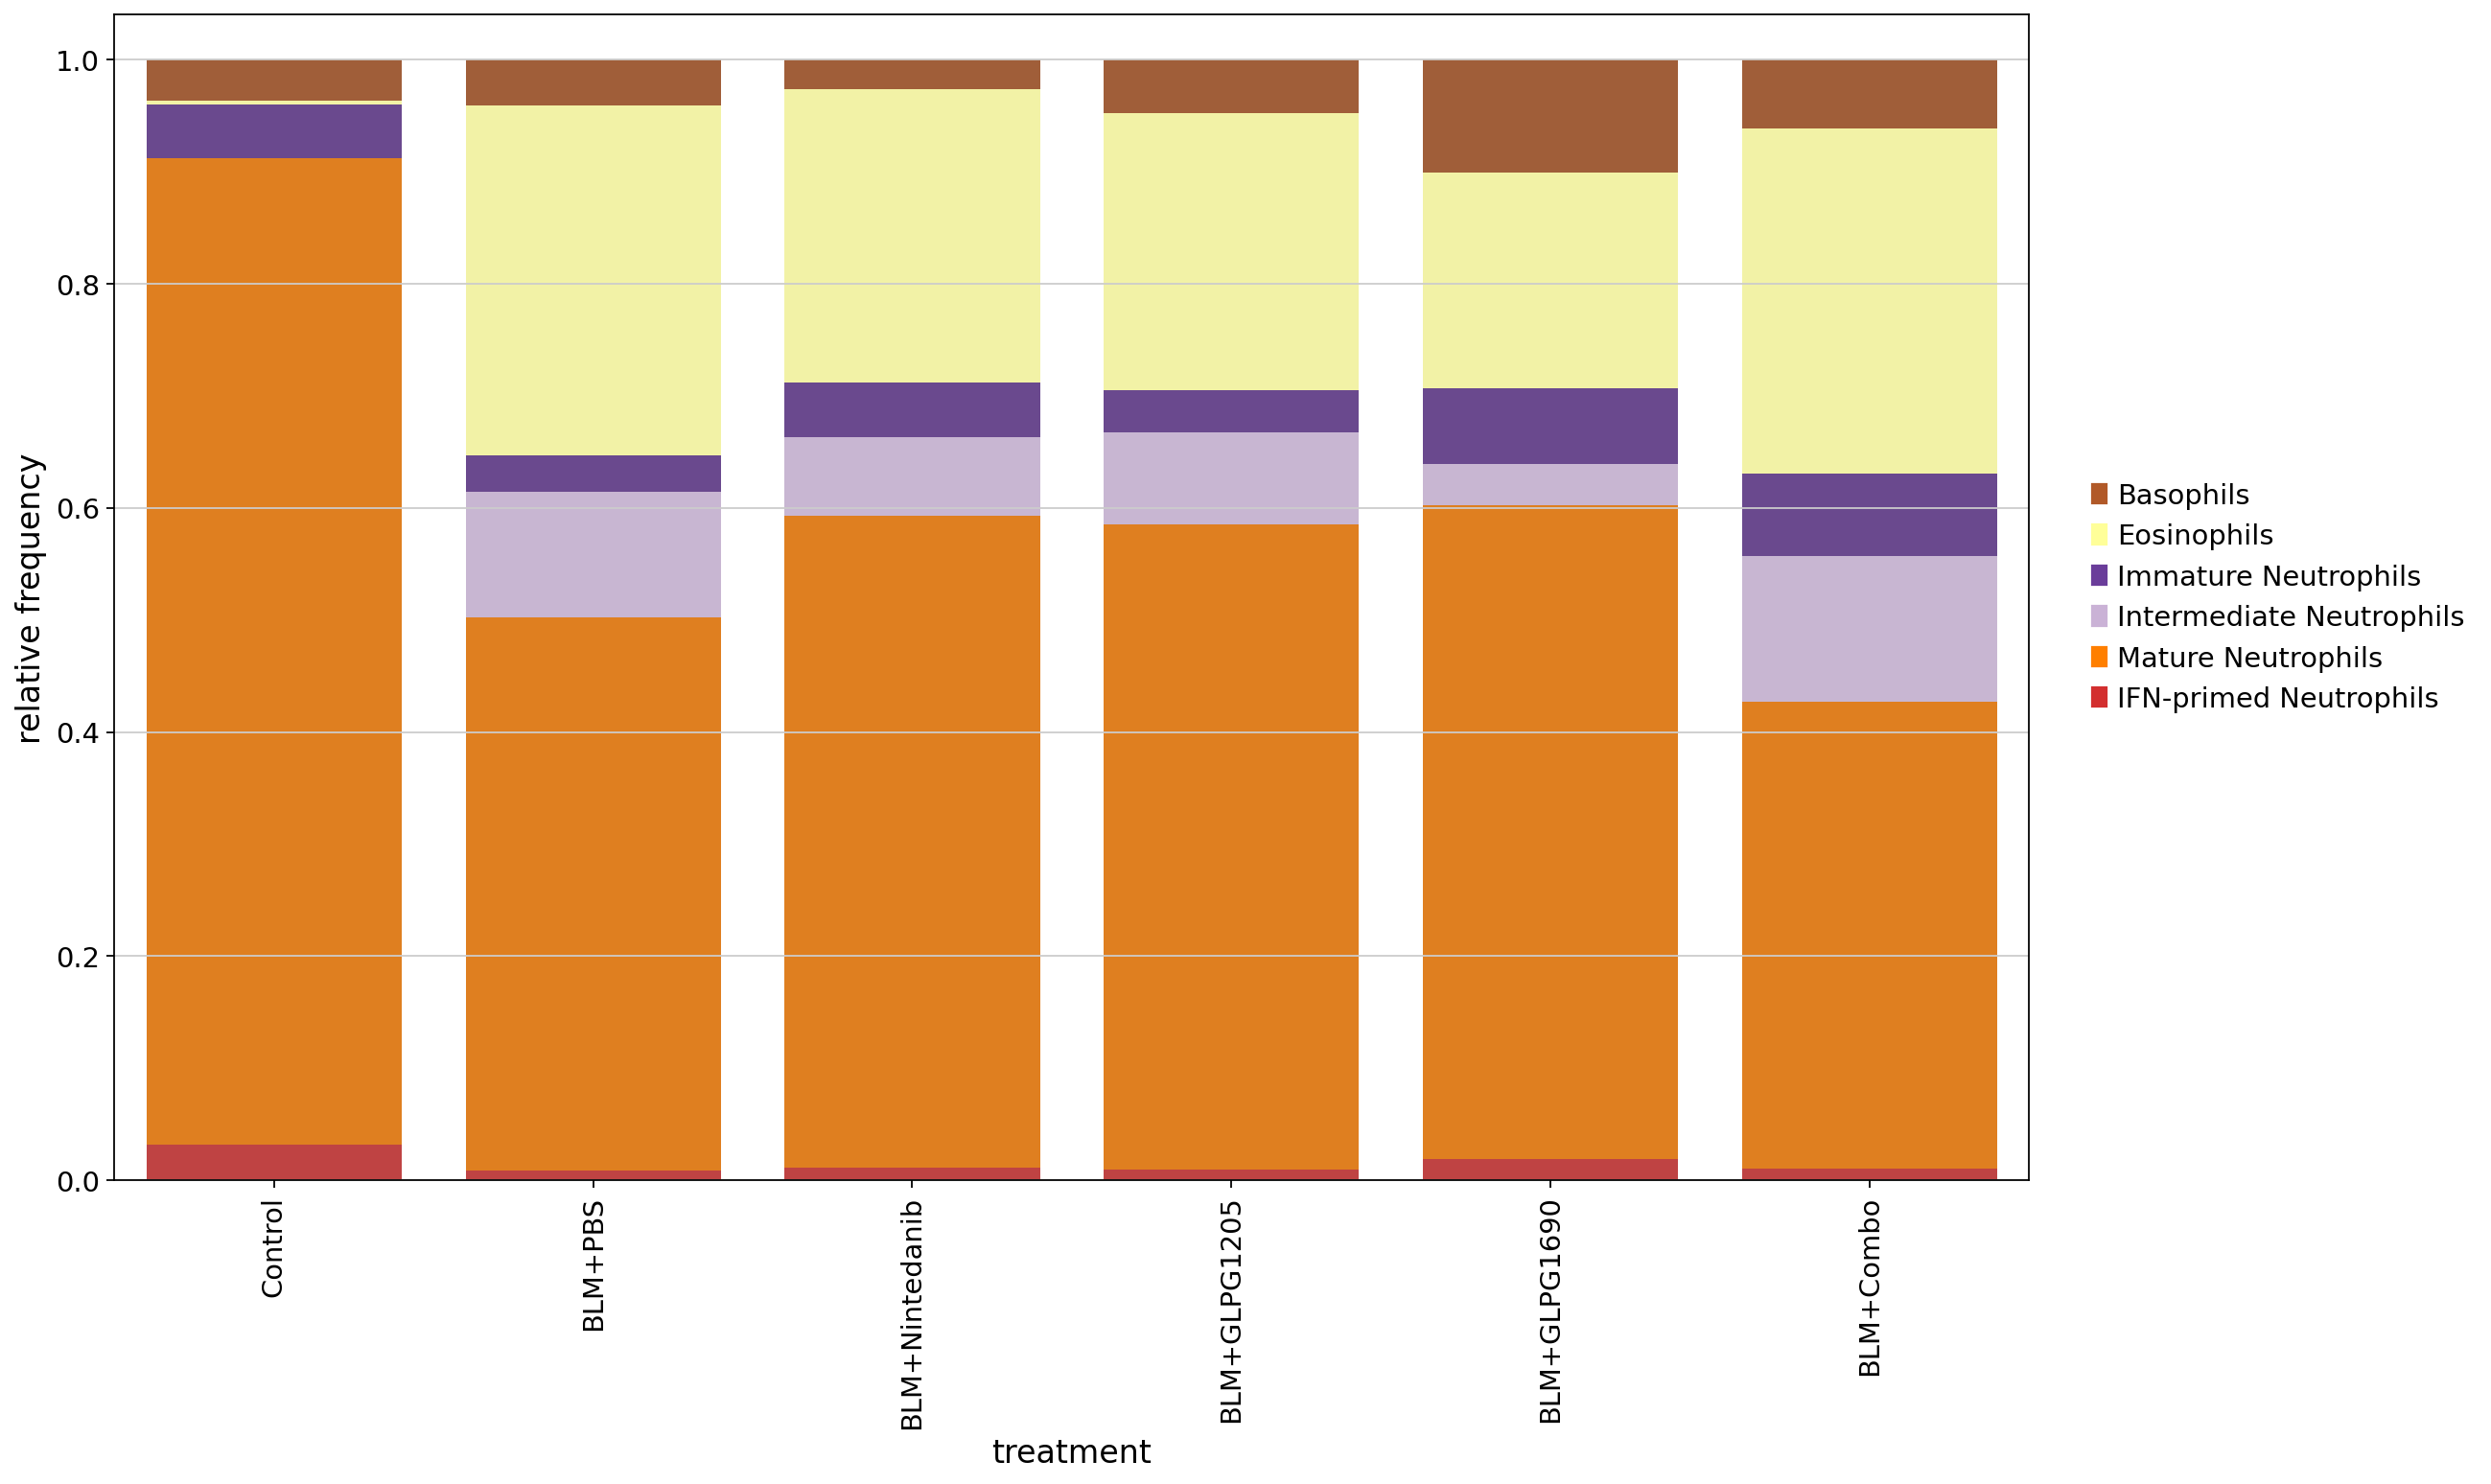

In [18]:
## cell type frequencies per treatment category
sct.plot.cluster_composition_stacked_barplot(relFreqs, xlabel = xlabel, figsize = (16,10), order = order,
                              colors = list(cols), width = 0.8,
                              save = out_dir + 'relfreqs_treatment.pdf')

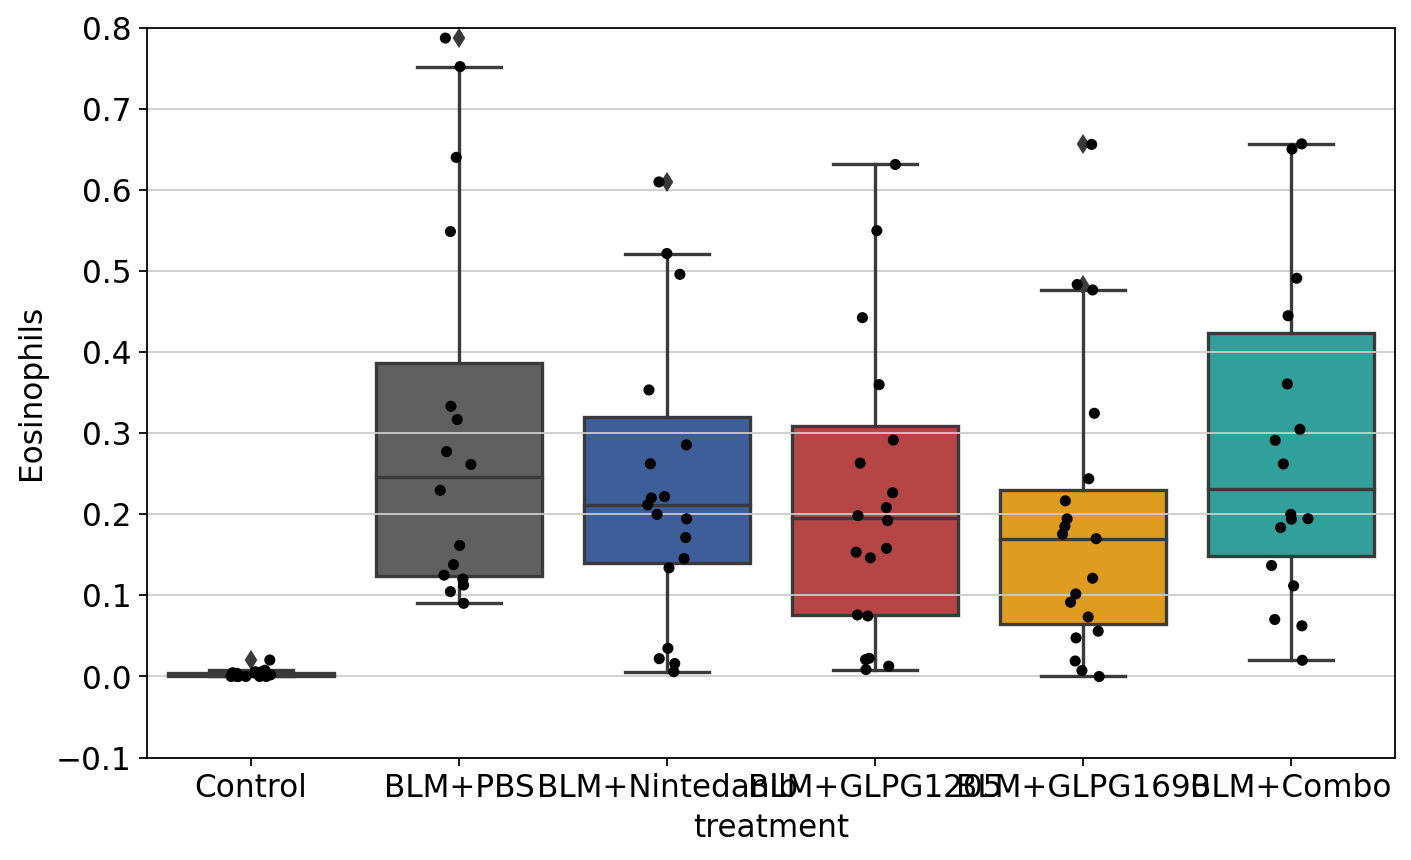

In [19]:
## box plot of eosinophils
plt.figure(figsize=(10, 6))
ax = sb.boxplot(x='treatment', y='Eosinophils', data=relFreqs, order=order, palette=treatment_colors)

## add individual data points on top
sb.stripplot(x='treatment', y='Eosinophils', data=relFreqs, order=order, color='black', size=5, jitter=True, ax=ax)
## set y-axis limits
ax.set_ylim(-0.1, 0.8)

## save fig
plt.savefig(out_dir + 'boxplot_rel_freq_eosinophils.pdf')

plt.show()

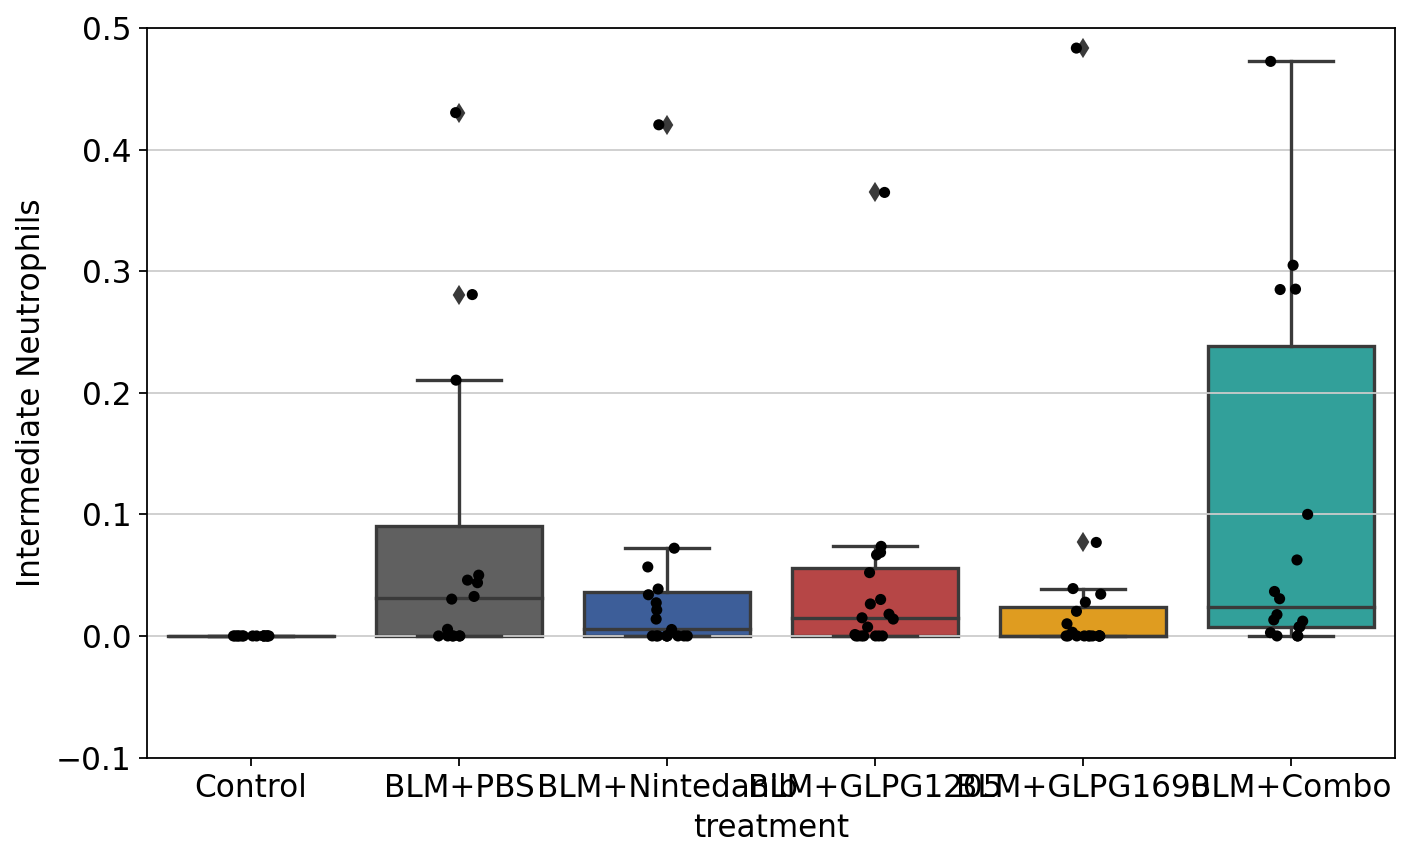

In [20]:
## box plot of intermediate neutrophils
plt.figure(figsize=(10, 6))
ax = sb.boxplot(x='treatment', y='Intermediate Neutrophils', data=relFreqs, order=order, palette=treatment_colors)

## add individual data points on top
sb.stripplot(x='treatment', y='Intermediate Neutrophils', data=relFreqs, order=order, color='black', size=5, jitter=True, ax=ax)
## set y-axis limits
ax.set_ylim(-0.1, 0.5)

## save fig
plt.savefig(out_dir + 'boxplot_rel_freq_intermediate_neutrophils.pdf')

plt.show()

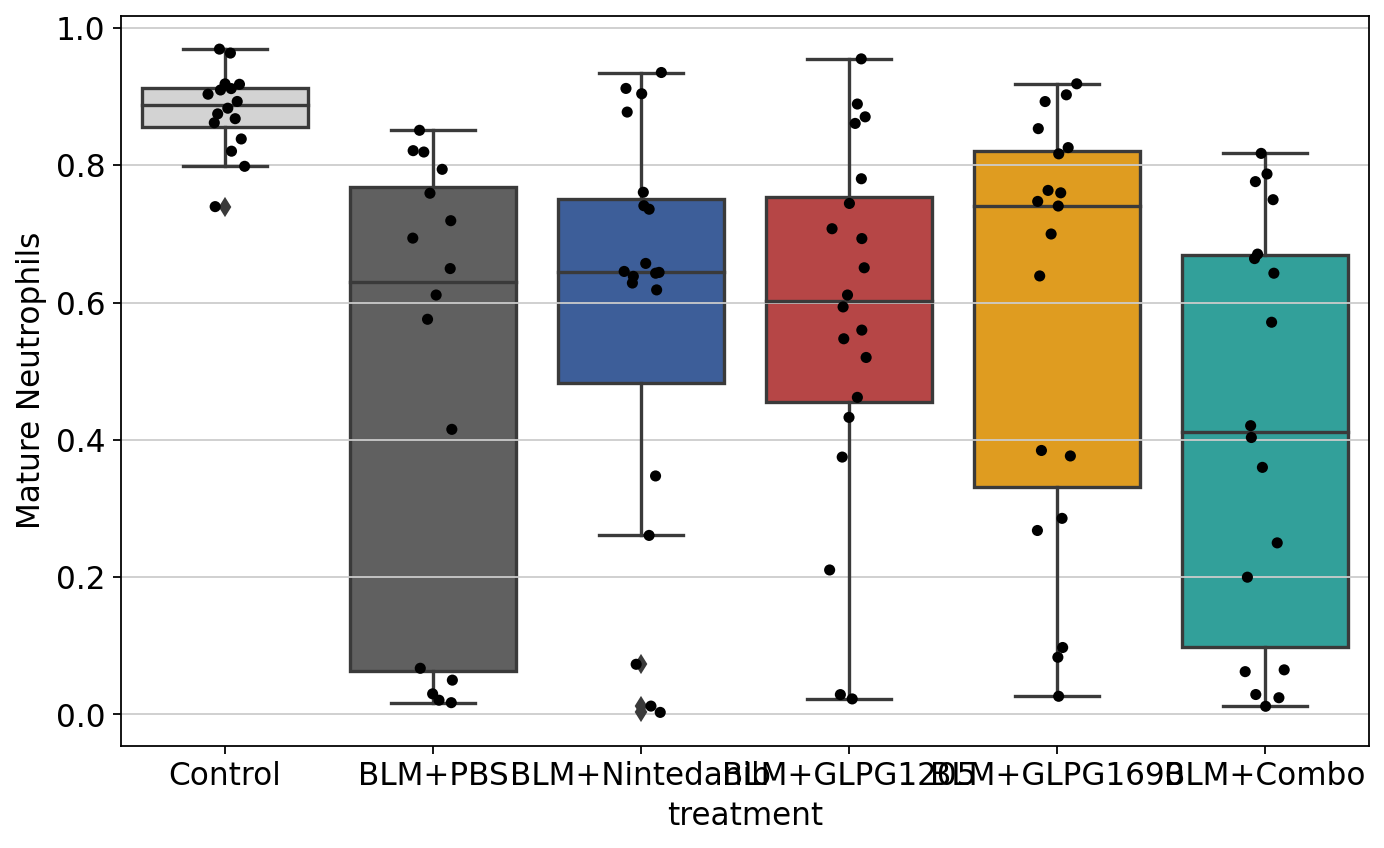

In [21]:
## box plot of mature neutrophils
plt.figure(figsize=(10, 6))
ax = sb.boxplot(x='treatment', y='Mature Neutrophils', data=relFreqs, order=order, palette=treatment_colors)

## add individual data points on top
sb.stripplot(x='treatment', y='Mature Neutrophils', data=relFreqs, order=order, color='black', size=5, jitter=True, ax=ax)

## save fig
plt.savefig(out_dir + 'boxplot_rel_freq_mature_neutrophils.pdf')

plt.show()

In [22]:
## frequency table
xlabel = 'treatment_time'
cell_types_label = 'cell_type'
cols = adata.uns['%s_colors' %cell_types_label]
celltypes = adata.obs[cell_types_label].cat.categories

relFreqs = sct.calc.relative_frequencies(adata, group_by = cell_types_label, xlabel = xlabel, condition = None)
relFreqs.head(2)

,Basophils,Eosinophils,Immature Neutrophils,Intermediate Neutrophils,Mature Neutrophils,IFN-primed Neutrophils,treatment_time
d100BLM_Combo48,0.0,0.291312,0.005111,0.691652,0.011925,0.000000,BLM+Combo_d10
d100BLM_G120528,0.0,0.158055,0.009119,0.364742,0.462006,0.006079,BLM+GLPG1205_d10


In [23]:
order = ['Control_d10','Control_d21','BLM+PBS_d10','BLM+PBS_d21',
         'BLM+Nintedanib_d10','BLM+Nintedanib_d21',
         'BLM+GLPG1205_d10','BLM+GLPG1205_d21',
         'BLM+GLPG1690_d10','BLM+GLPG1690_d21',
         'BLM+Combo_d10','BLM+Combo_d21']

Saving Figure to 
/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig2/relfreqs_treatment_time.pdf

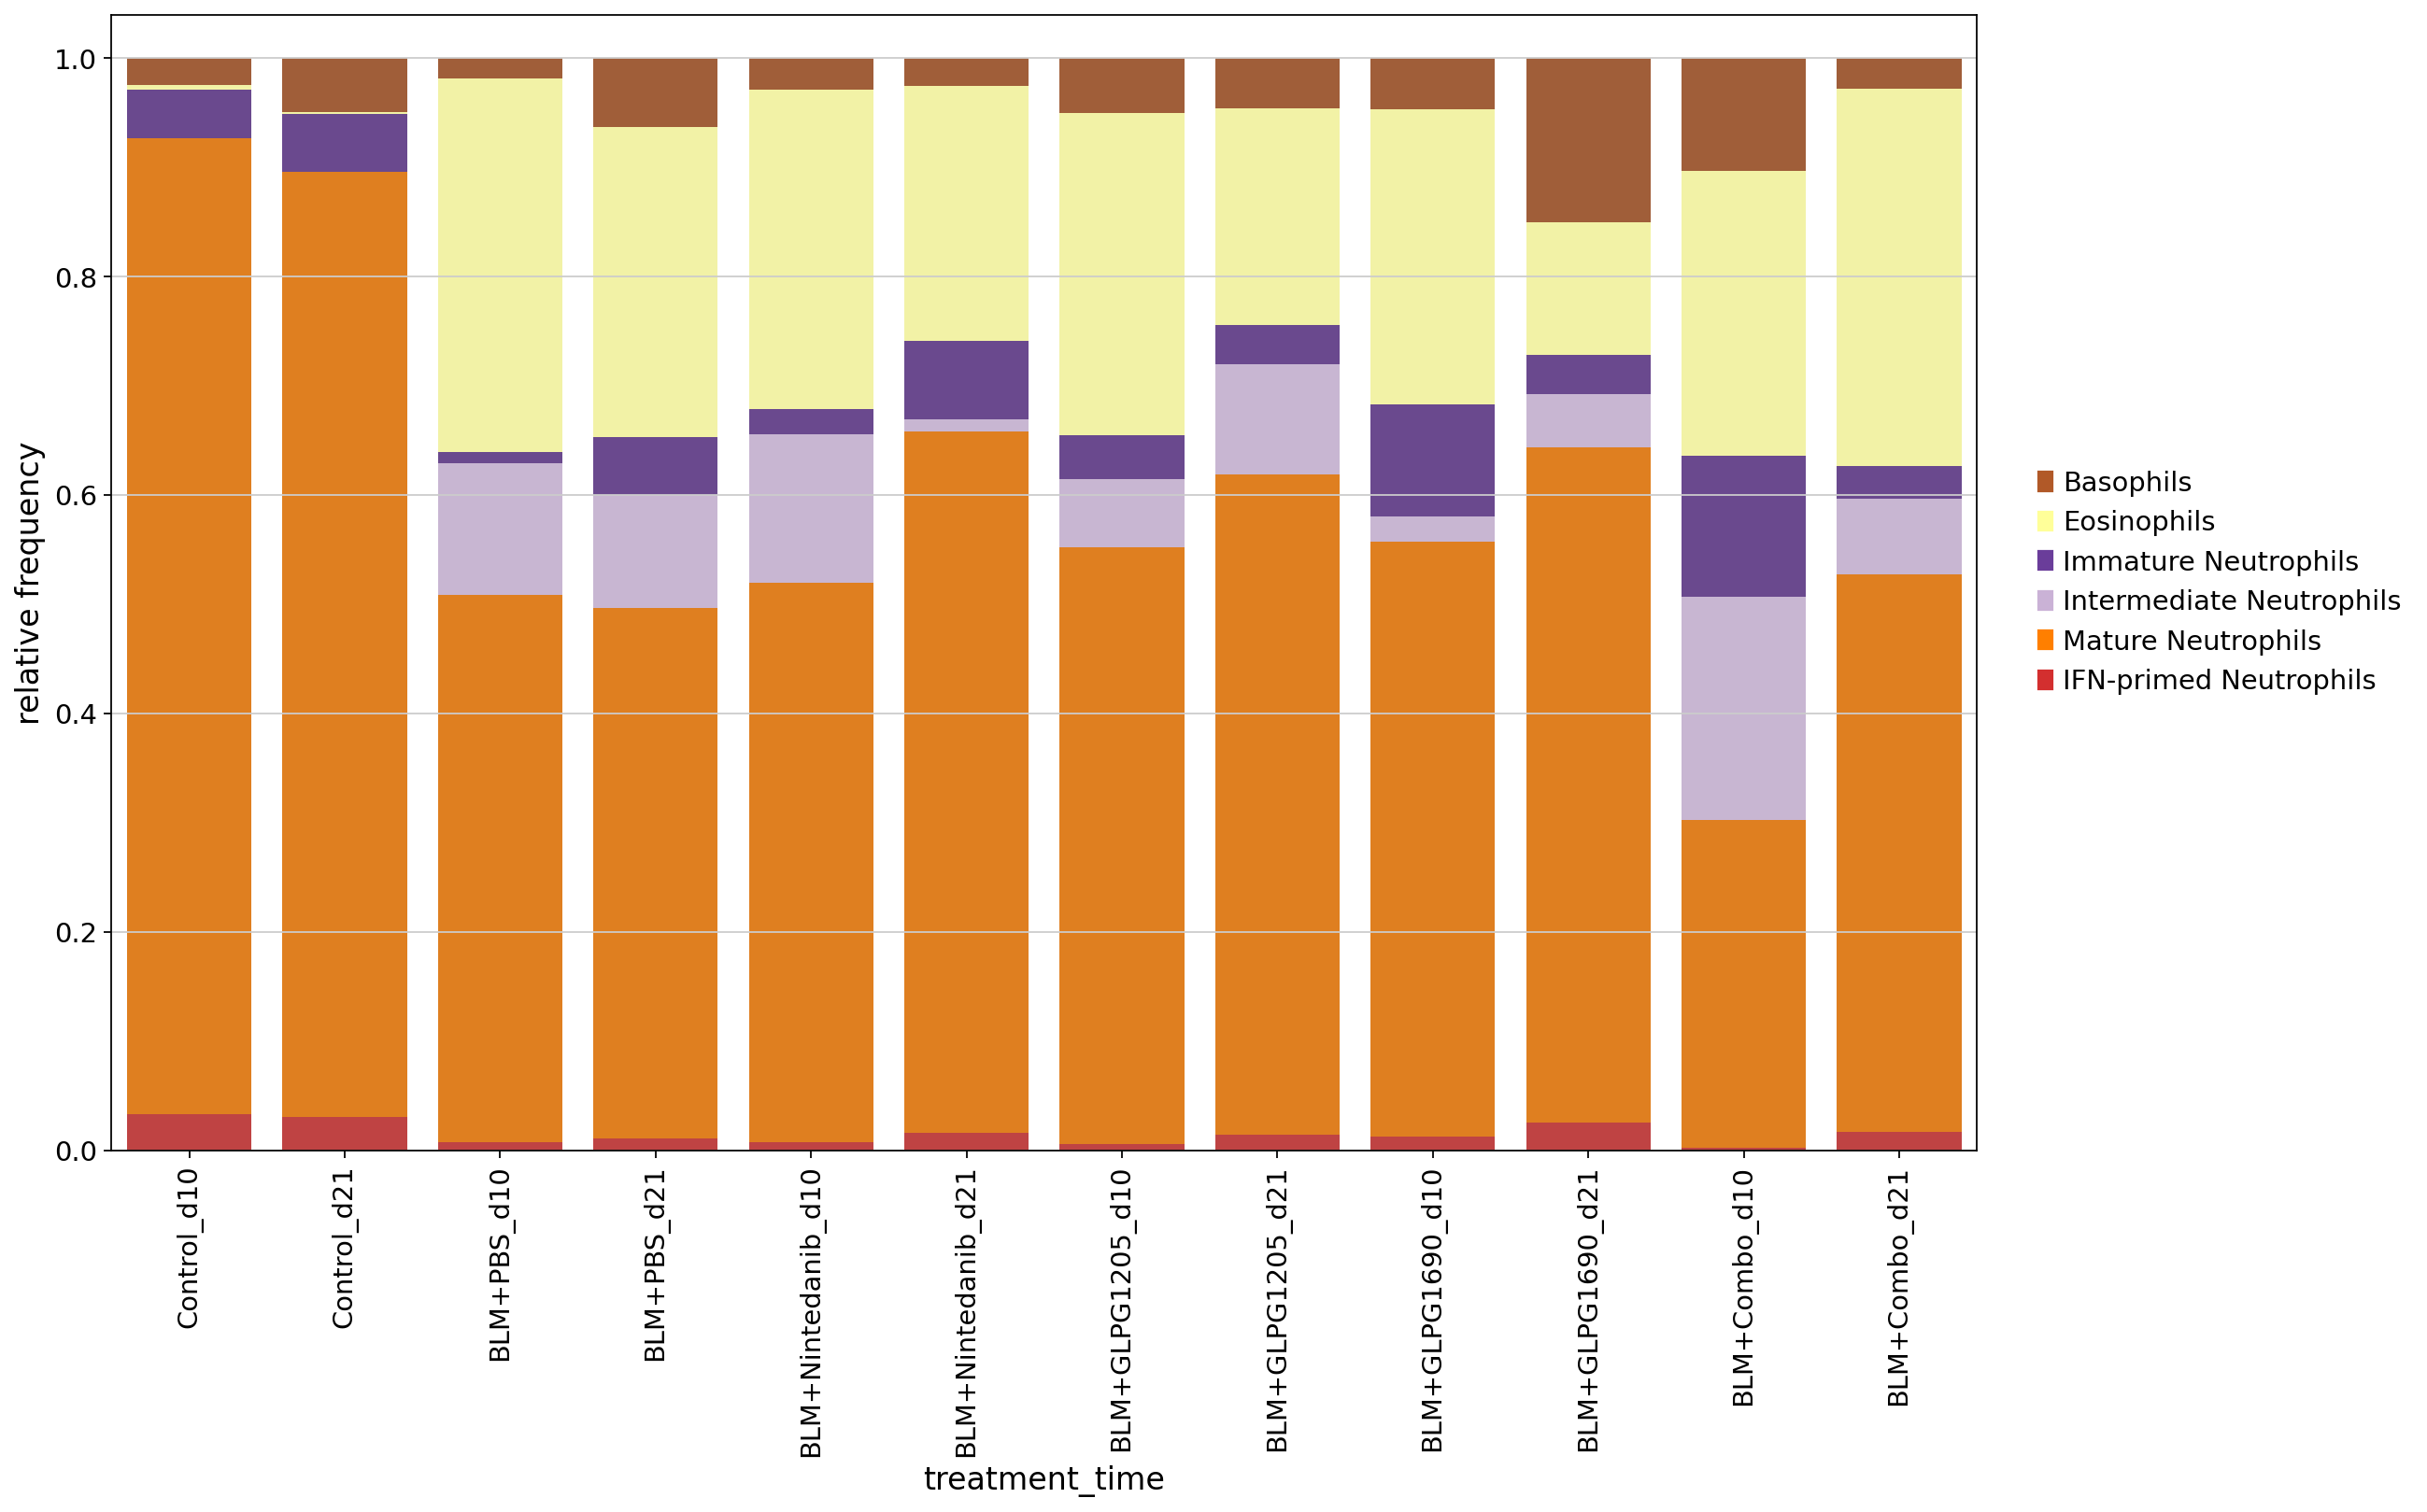

In [24]:
## cell type frequencies per treatment time category
sct.plot.cluster_composition_stacked_barplot(relFreqs, xlabel = xlabel, figsize = (16,10), order = order,
                              colors = list(cols), width = 0.8,
                              save = out_dir  + 'relfreqs_treatment_time.pdf')

### Expression of therapeutic targets of clinically approved drugs

- Mepolizumab and Reslizumab: IL-5
- Benralizumab: IL-5Rα
- Dupilumab and Pascolizumab: IL-4Rα
- Lirentelimab: Siglec-8
- Tezepelumab: TSLP
- Lebrikizumab and Tralokinumab: IL-13

In [25]:
targets = [
    #'Il5','Il-5',
    #'Il5ra', 'Il5r',
    'Il4ra',
    'Siglecf',
    'Tslp',
    'Il13'
]

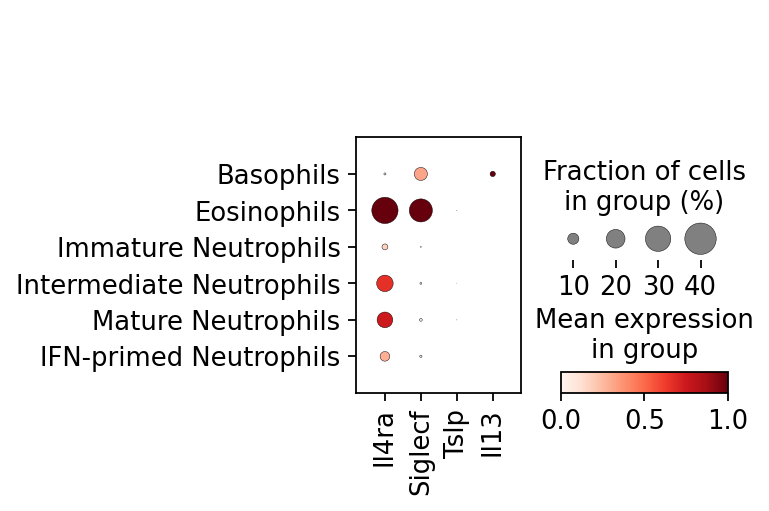

In [26]:
sc.pl.dotplot(adata,
              var_names = targets,
              groupby = 'cell_type',
              standard_scale = 'var',
              save = 'biologicals_target_expression.pdf'
             )